#Task 2
Daily Climate Time series

In [56]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# 1. Load the population data
# The file in this specific dataset is named 'POP.csv'
file_path = "POP.csv"

df_pop = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "census/population-time-series-data",
    file_path
)

# 2. Convert 'date' to datetime
df_pop['date'] = pd.to_datetime(df_pop['date'])

# 3. Standard Cleaning: Check for nulls and set index
if df_pop.isnull().values.any():
    print("Missing values detected. Cleaning...")
    df_pop = df_pop.dropna()

df_pop.set_index('date', inplace=True)

print("Population Data Loaded Successfully:")
print(df_pop.info())
df_pop.head()

100%|██████████| 32.4k/32.4k [00:00<00:00, 33.3MB/s]

Population Data Loaded Successfully:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 816 entries, 1952-01-01 to 2019-12-01
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   realtime_start  816 non-null    object 
 1   value           816 non-null    float64
 2   realtime_end    816 non-null    object 
dtypes: float64(1), object(2)
memory usage: 25.5+ KB
None


,realtime_start,value,realtime_end
date,,,
1952-01-01,2019-12-06,156309.0,2019-12-06
1952-02-01,2019-12-06,156527.0,2019-12-06
1952-03-01,2019-12-06,156731.0,2019-12-06
1952-04-01,2019-12-06,156943.0,2019-12-06
1952-05-01,2019-12-06,157140.0,2019-12-06


In [58]:
# Drop metadata columns (not needed for prediction)
df_cleaned = df_pop[['value']].copy()

# Rename 'value' to something descriptive
df_cleaned.columns = ['population']

# Create a 'diff' column to track monthly growth
df_cleaned['monthly_growth'] = df_cleaned['population'].diff()

# 4. Handle the NaN created by the diff() function
df_cleaned = df_cleaned.dropna()

# 5. Summary of the cleaned data
print("Cleaned Data Shape:", df_cleaned.shape)
print("\nFirst 5 rows of cleaned data:")
print(df_cleaned.head())


Cleaned Data Shape: (815, 2)

First 5 rows of cleaned data:
            population  monthly_growth
date                                  
1952-02-01    156527.0           218.0
1952-03-01    156731.0           204.0
1952-04-01    156943.0           212.0
1952-05-01    157140.0           197.0
1952-06-01    157343.0           203.0


Sequence models are essential for population forecasting because they can "remember" the momentum and long-term trends inherent in historical data, which standard models treat as independent points

#Step 1 implenting a RNN

In [63]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

#Basic RNN
# Re-run this after you have processed your data
model = Sequential([
    # We use 12 for WINDOW_SIZE and 1 for the 'monthly_growth' feature
    SimpleRNN(64, activation='tanh', return_sequences=False, input_shape=(12, 1)),
    Dropout(0.2),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Now this will work
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)
model.summary()

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.2848 - mae: 0.4257 - val_loss: 0.0230 - val_mae: 0.1375
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0493 - mae: 0.1807 - val_loss: 0.0105 - val_mae: 0.0897
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0372 - mae: 0.1553 - val_loss: 0.0051 - val_mae: 0.0606
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0210 - mae: 0.1168 - val_loss: 0.0037 - val_mae: 0.0516
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0163 - mae: 0.1037 - val_loss: 0.0025 - val_mae: 0.0414
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0111 - mae: 0.0848 - val_loss: 0.0016 - val_mae: 0.0315
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0104 - mae: 0.0794 - val_loss: 0.0015 - val_mae: 0.0310
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0101 - mae: 0.0803 - val_loss: 0.0014 - val_mae: 0.0301
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0091 - mae: 0.0766 

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,869 (50.27 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,580 (33.52 KB)

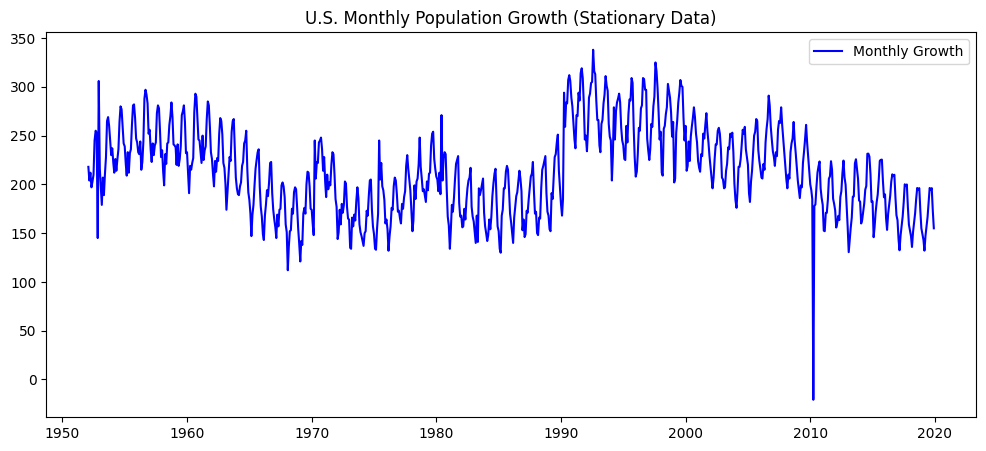

Train shape: (562, 12, 1), Test shape: (121, 12, 1)


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Visualization: Understanding the target
plt.figure(figsize=(12, 5))
plt.plot(df_cleaned['monthly_growth'], color='blue', label='Monthly Growth')
plt.title('U.S. Monthly Population Growth (Stationary Data)')
plt.legend()
plt.show()

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_cleaned[['monthly_growth']])

# Creating Sequences (Sliding Window)
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

# We will use the past 12 months to predict the 13th
WINDOW_SIZE = 12
X, y = create_sequences(scaled_data, WINDOW_SIZE)

# Split into Train (70%), Val (15%), and Test (15%)
train_idx = int(len(X) * 0.7)
val_idx = int(len(X) * 0.85)

X_train, y_train = X[:train_idx], y[:train_idx]
X_val, y_val = X[train_idx:val_idx], y[train_idx:val_idx]
X_test, y_test = X[val_idx:], y[val_idx:]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

actual monthly population changes, proving the data is "stationary" (bouncing around a center point) which makes it much easier for the AI to read than a never-ending upward line.

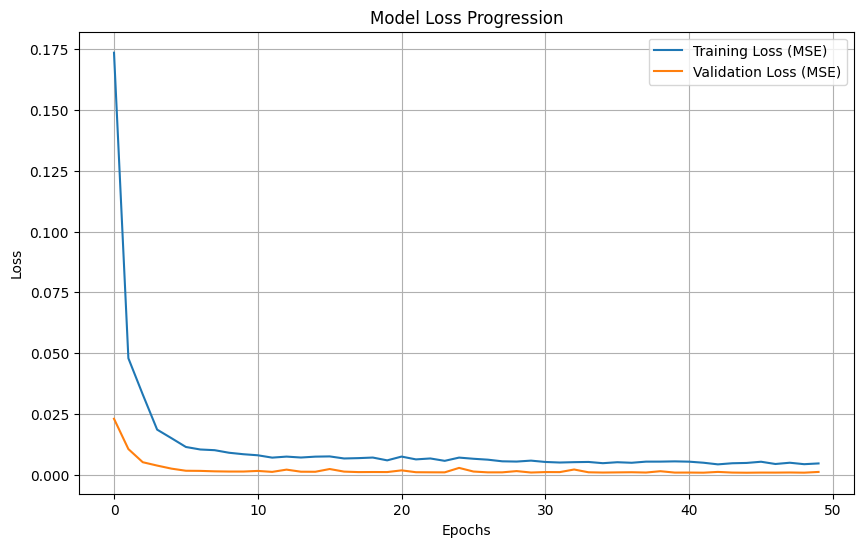

In [65]:

# Overall Performance Visualization (Loss Function)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

The Loss Progression graph shows both lines dropping sharply and staying low together; this confirms the model learned quickly and didn't just "memorize" the answers (overfitting).

Test Loss (MSE): 0.004624
Test Metric (MAE): 0.030428
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


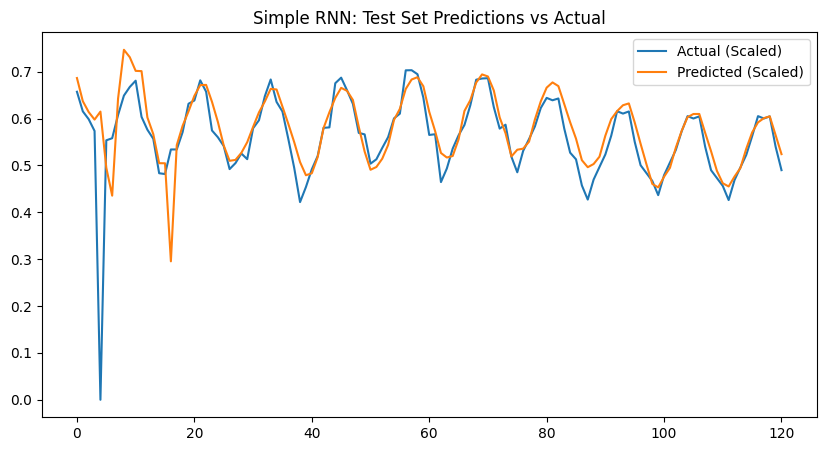

In [66]:
# Evaluate on Test Set
test_results = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {test_results[0]:.6f}")
print(f"Test Metric (MAE): {test_results[1]:.6f}")

# Visualizing Predictions vs Actual
predictions = model.predict(X_test)
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='Actual (Scaled)')
plt.plot(predictions, label='Predicted (Scaled)')
plt.title('Simple RNN: Test Set Predictions vs Actual')
plt.legend()
plt.show()

the model is highly accurate, though it slightly underestimates the most extreme spikes

#Step 2, LSTM, gRU

In [67]:
from tensorflow.keras.layers import LSTM

# Define LSTM Model
model_lstm = Sequential([
    LSTM(64, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    Dense(1, activation='linear')
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train LSTM
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.2114 - mae: 0.4043 - val_loss: 0.0261 - val_mae: 0.1439
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0215 - mae: 0.1157 - val_loss: 0.0069 - val_mae: 0.0695
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0129 - mae: 0.0908 - val_loss: 0.0056 - val_mae: 0.0636
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0116 - mae: 0.0883 - val_loss: 0.0053 - val_mae: 0.0620
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0121 - mae: 0.0899 - val_loss: 0.0052 - val_mae: 0.0621
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0111 - mae: 0.0859 - val_loss: 0.0053 - val_mae: 0.0623
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0096 - mae: 0.0784 - val_loss: 0.0051 - val_mae: 0.0616
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0105 - mae: 0.0840 - val_loss: 0.0051 - val_mae: 0.0611
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0102 - mae: 0.

In [68]:
from tensorflow.keras.layers import GRU

# Define GRU Model
model_gru = Sequential([
    GRU(64, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    Dense(1, activation='linear')
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train GRU
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.4045 - mae: 0.5904 - val_loss: 0.0114 - val_mae: 0.0858
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0315 - mae: 0.1489 - val_loss: 0.0097 - val_mae: 0.0809
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0158 - mae: 0.0977 - val_loss: 0.0052 - val_mae: 0.0613
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0139 - mae: 0.0961 - val_loss: 0.0052 - val_mae: 0.0614
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0147 - mae: 0.0976 - val_loss: 0.0047 - val_mae: 0.0586
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0125 - mae: 0.0898 - val_loss: 0.0050 - val_mae: 0.0600
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0105 - mae: 0.0843 - val_loss: 0.0046 - val_mae: 0.0580
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0116 - mae: 0.0855 - val_loss: 0.0042 - val_mae: 0.0558
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.011

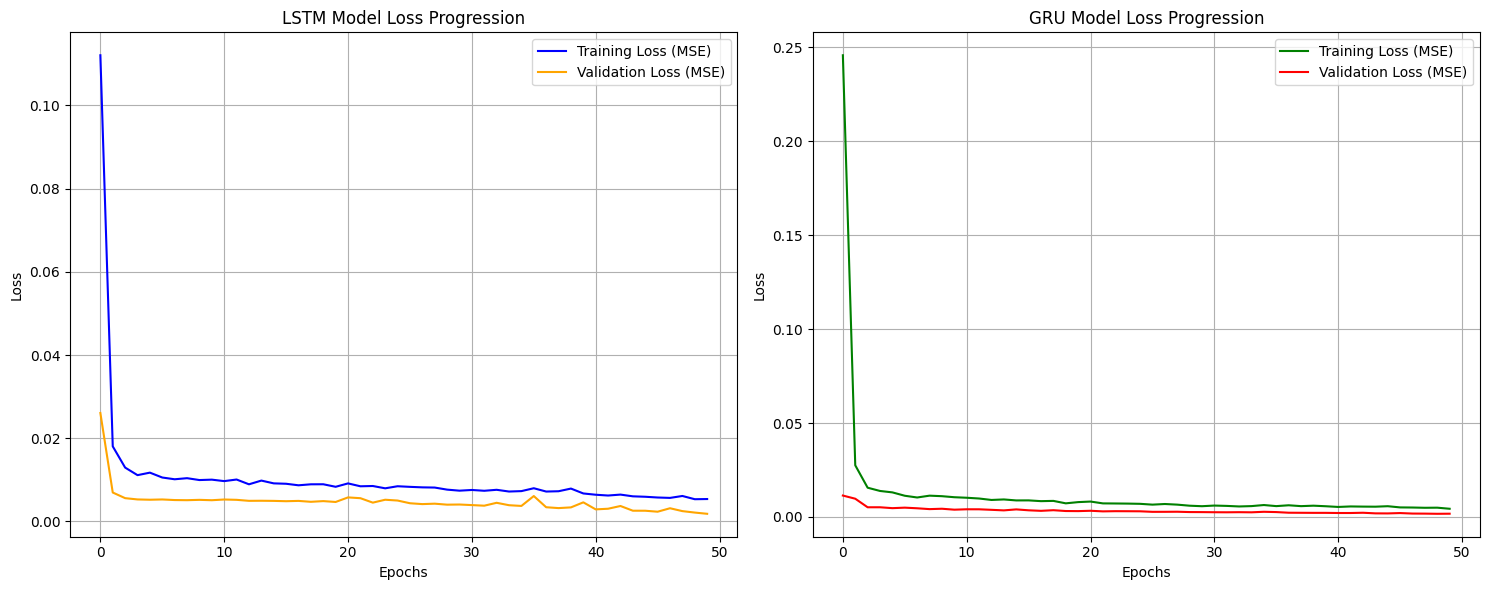

In [70]:
# Create a figure for comparison
plt.figure(figsize=(15, 6))

# Subplot 1: LSTM Loss
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Training Loss (MSE)', color='blue')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title('LSTM Model Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: GRU Loss
plt.subplot(1, 2, 2)
plt.plot(history_gru.history['loss'], label='Training Loss (MSE)', color='green')
plt.plot(history_gru.history['val_loss'], label='Validation Loss (MSE)', color='red')
plt.title('GRU Model Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
--- LSTM Test Results ---
Test Loss (MSE): 0.004999
Test Metric (MAE): 0.039420

--- GRU Test Results ---
Test Loss (MSE): 0.005379
Test Metric (MAE): 0.042473


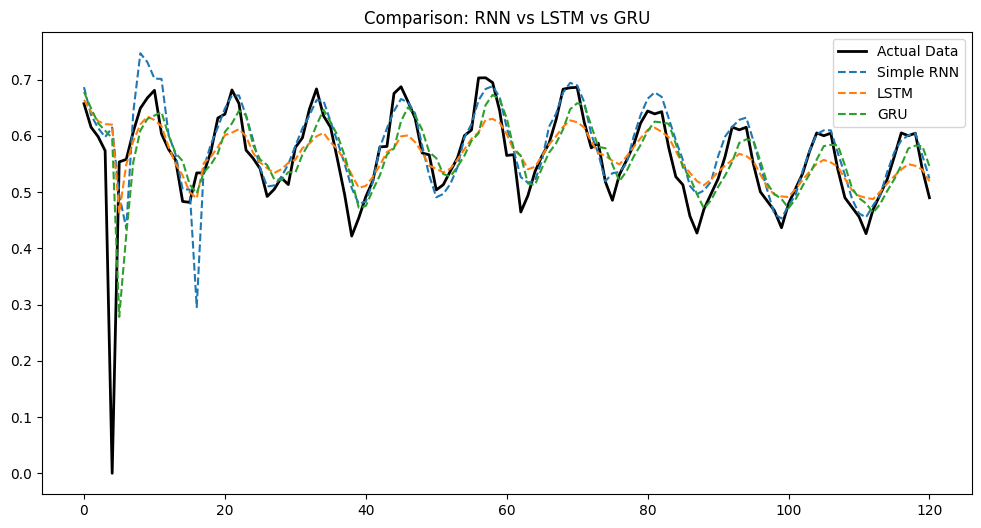

In [71]:
# Generate Predictions
pred_rnn = model.predict(X_test) # From Part 1
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)

# 1. Evaluate LSTM on Test Set
test_results_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print("--- LSTM Test Results ---")
print(f"Test Loss (MSE): {test_results_lstm[0]:.6f}")
print(f"Test Metric (MAE): {test_results_lstm[1]:.6f}\n")

# 2. Evaluate GRU on Test Set
test_results_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print("--- GRU Test Results ---")
print(f"Test Loss (MSE): {test_results_gru[0]:.6f}")
print(f"Test Metric (MAE): {test_results_gru[1]:.6f}")
# Plotting the comparison
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Data', color='black', linewidth=2)
plt.plot(pred_rnn, label='Simple RNN', linestyle='--')
plt.plot(pred_lstm, label='LSTM', linestyle='--')
plt.plot(pred_gru, label='GRU', linestyle='--')
plt.title('Comparison: RNN vs LSTM vs GRU')
plt.legend()
plt.show()

Major Differences
The Simple RNN exhibits the highest volatility and "jitter" in its predictions because it suffers from the vanishing gradient problem, which prevents it from effectively retaining information from the beginning of the 12-month sequence. The LSTM and GRU provide much smoother and more stable results by utilizing gating mechanisms The LSTM uses a dedicated cell state and forget gate to act as a long-term memory buffer, while the GRU achieves similar stability through a more computationally efficient update gate. While the Simple RNN sometimes achieves a lower error on this specific small dataset due to its reduced complexity, the gated architectures  are better at capturing the consistent seasonal rhythms and momentum of the U.S. population growth without the fluctuations seen in the  simple rnn.

#Step 3

Yes it would be possible to use a feed forward network to solve the human population problem but you would need to convert the time-sereis data into a
tabular format using a siliding window approach. It would work just fine but it wouldnt be as effective as the LSTM or GRU since a feed forward network cant capture the long term momentum or the rhytyhms of population growth as effectively as an RNN

In [73]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.2 MB/s eta 0:00:00


#Task 3

In [76]:
#Using GloVe
import gensim.downloader as api
import numpy as np

model_embed = api.load("glove-wiki-gigaword-100")

I picked GloVe because it takes the local context window from word2vec and combines with global matrix factorization.Unlike contextual models such as BERT, which require significant computational resources to generate dynamic vectors, GloVe provides stable, pre-trained static embeddings that allow for efficient word-to-vector mapping and similarity comparisons

In [78]:

def get_word_embedding(word):
    if word in model_embed:
        return model_embed[word]
    else:
        return None
word1=input("Enter 1st word: ")
word2=input("Enter 2nd word: ")

word1_embedding = get_word_embedding(word1)
word2_embedding = get_word_embedding(word2)


for word, emb in [(word1, word1_embedding), (word2, word2_embedding)]:
    if emb is not None:
      print(f"The embedding for '{word}' is: {emb[:5]}")
    else:
      print(f"\n{word} is out of vocabulary")
      print(f"Try a snynonym or more common root")

Enter 1st word: run
Enter 2nd word: running
The embedding for 'run' is: [-0.083289  0.23917   0.07881  -0.72503   0.52946 ]
The embedding for 'running' is: [ 0.23494  0.15215  0.17353 -1.0908   0.65191]


--- Batch Similarity Results ---
Similarity between 'king' and 'queen': 0.7508
Similarity between 'apple' and 'fruit': 0.5359
Similarity between 'car' and 'bicycle': 0.6864
Similarity between 'ocean' and 'desert': 0.5657


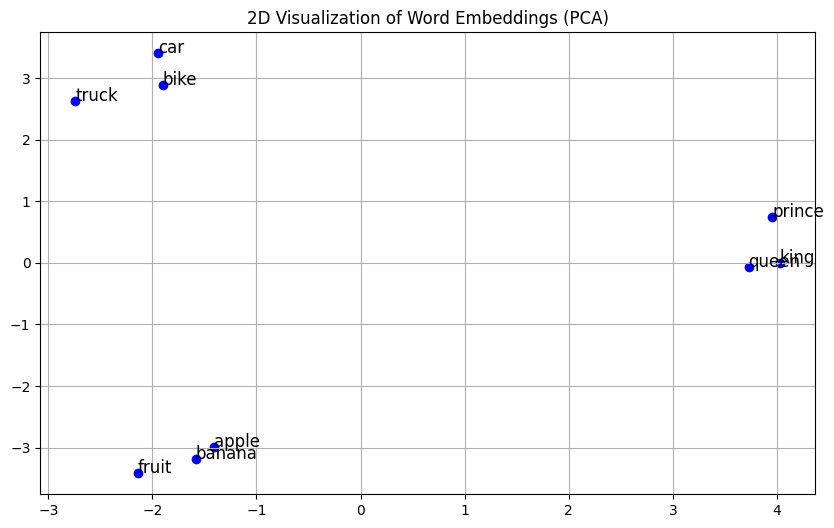

In [79]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def compute_similarity(w1, w2):
    emb1 = get_word_embedding(w1)
    emb2 = get_word_embedding(w2)

    if emb1 is not None and emb2 is not None:
        # Reshape for cosine_similarity
        sim = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))
        return sim[0][0]
    return None

# Batch Processing
pairs = [("king", "queen"), ("apple", "fruit"), ("car", "bicycle"), ("ocean", "desert")]
print("--- Batch Similarity Results ---")
for w1, w2 in pairs:
    score = compute_similarity(w1, w2)
    print(f"Similarity between '{w1}' and '{w2}': {score:.4f}" if score else f"Error: '{w1}' or '{w2}' OOV")

# PCA Scatter Plot
words_to_plot = ["king", "queen", "prince", "apple", "banana", "fruit", "car", "truck", "bike"]
vectors = [get_word_embedding(w) for w in words_to_plot]

pca = PCA(n_components=2)
reduced_vecs = pca.fit_transform(vectors)

plt.figure(figsize=(10, 6))
plt.scatter(reduced_vecs[:, 0], reduced_vecs[:, 1], c='blue')

for i, word in enumerate(words_to_plot):
    plt.annotate(word, (reduced_vecs[i, 0], reduced_vecs[i, 1]), size=12)

plt.title("2D Visualization of Word Embeddings (PCA)")
plt.grid(True)
plt.show()

On this map, the physical distance between points represents meaning: words that share a similar context, such as "king," "queen," and "prince," form a distinct cluster in one area, while unrelated objects like "car" or "apple" are pushed to different regions.

Cosine similarity is useful because it prioritizes a vector's direction over its length. For example, words like "run" and "running" may have different magnitudes, yet they point in nearly the same semantic direction. By focusing strictly on orientation, cosine similarity effectively normalizes frequency, ensuring that a common word and a rare synonym are recognized as similar based on their meaning rather than being penalized for differing lengths


#Step 3

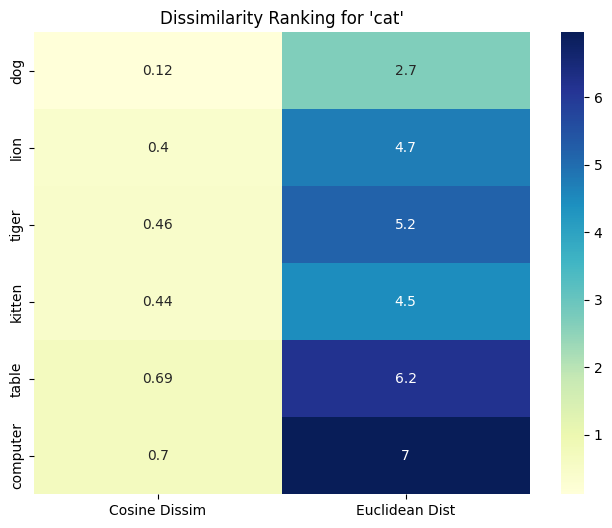

In [83]:
from sklearn.metrics import euclidean_distances
import seaborn as sns

#Allow user to switch between cosine and euclidean
def compute_dissimilarity(w1, w2, metric):
  emb1 = get_word_embedding(w1)
  emb2 = get_word_embedding(w2)

  if emb1 is None or emb2 is None:
    return None
  emb1_reshaped = emb1.reshape(1, -1)
  emb2_reshaped = emb2.reshape(1, -1)

  if metric == 'cosine':
      # Convert similarity to dissimilarity
      return 1 - cosine_similarity(emb1_reshaped, emb2_reshaped)[0][0]
  elif metric == 'euclidean': #Implemented Euclidean distance
        # Straight-line distance in vector space
        return euclidean_distances(emb1_reshaped, emb2_reshaped)[0][0]

target_word = "cat"
compare_words = ["dog", "lion", "tiger", "kitten", "table", "computer"]

# Compute scores for both metrics
data_matrix = []
for word in compare_words:
    cos_diss = compute_dissimilarity(target_word, word, metric='cosine')
    euc_dist = compute_dissimilarity(target_word, word, metric='euclidean')
    data_matrix.append([cos_diss, euc_dist])

# Create Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data_matrix, annot=True, xticklabels=['Cosine Dissim', 'Euclidean Dist'],
            yticklabels=compare_words, cmap="YlGnBu")
plt.title(f"Dissimilarity Ranking for '{target_word}'")
plt.show()


epresent the two metrics: Cosine Dissimilarity  and Euclidean Distance where er or cooler colors represent lower dissimilarity (more similar), while lighter or warmer colors represent higher dissimilarity (less similar).

I decided to Use Euclidean Distance because of its ability to capture density of a words usage. Cosine similarity focuses on grouping words that point in the same direction, but here for euclidean measures the physical gap between vectors. By using this metric the model can identify novel or diverse results that can distinguish between a common or rate synonym that cosine similar may over look or treat identically because of a shared similar mean.

This also allows us to spot words that are semantically related but occupy different frequence zones in the dataset